In [1]:
import re
from pathlib import Path
import warnings
import os

import numpy as np
import pandas as pd
import scipy
from PIL import Image
from tqdm.auto import tqdm
from sklearn.preprocessing import StandardScaler
from nptdms import TdmsFile
from scipy.signal import stft, butter, lfilter
import matplotlib.pyplot as plt
from joblib import load

warnings.filterwarnings("ignore")


/home/patryk/Desktop/venv/ML_venv/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
tdms_dir = r'/home/patryk/Desktop/engineering_thesis/dane_temp'

tdms_list = []

for root, dirs, files in os.walk(tdms_dir):
    print(f"There are {len(dirs)} directories and {len(files)} files in {root}")
    
    for file in files:
        if file.endswith(".tdms"):
            tdms_list.append(os.path.join(root, file))

pattern = r'ziemowit_(\d)'
data_list = []

for tdms_file_path in tdms_list:
    tdms_file = TdmsFile.read(tdms_file_path)
    
    filename = os.path.basename(tdms_file_path)
    file_id = os.path.splitext(filename)[0]   
    
    label_match = re.findall(pattern, filename)
    label = label_match[0] if label_match else None 

    if label:
        for group in tdms_file.groups():
            for channel in group.channels():
                data_len = len(channel.data)
                
                if 1000 <= data_len <= 100000000 and channel.name == 'Voltage':
                    data_list.append({
                        'excitation': channel.data,
                        'id': label,
                        'identifier': file_id   
                    })

df_magnitude = pd.DataFrame(data_list)
df_magnitude.head()

There are 0 directories and 24 files in /home/patryk/Desktop/engineering_thesis/dane_temp


,excitation,id,identifier
0,"[-0.43819263999999997, 9.452074082000001, 10.4...",3,ziemowit_3kotwa2
1,"[10.465749096, 10.465749096, 10.465749096, 10....",3,ziemowit_3kotwa1
2,"[10.465749096, 8.54585691, 4.269226118000001, ...",4,ziemowit_4kotwa3
3,"[-8.907592466, -5.9258765, 5.351457322, 10.465...",3,ziemowit_3kotwa3
4,"[5.38111186, 9.540718830000001, 10.465749096, ...",4,ziemowit_4kotwa2


In [3]:
np.savetxt("/home/patryk/Desktop/MASTER_THIESIS/fpga_prep/test_data_anchor.txt", df_magnitude['excitation'][0])

In [5]:
np.save(r"/home/patryk/Desktop/MASTER_THIESIS/fpga_prep/test_data.npy", df_magnitude['excitation'][0])

In [ ]:
def bandpass_filter(data, lowcut, highcut, fs, order=5):
    nyquist = 0.5 * fs  # Częstotliwość Nyquista
    low = lowcut / nyquist
    high = highcut / nyquist
    
    # Projektowanie filtra
    b, a = butter(order, [low, high], btype='band')
    # Filtrowanie sygnału
    y = lfilter(b, a, data)
    return y

df_magnitude['excitation'] = df_magnitude['excitation'].apply(lambda x: bandpass_filter(x, 3000, 8000, 50000))

df_magnitude['type_id'] = df_magnitude['id'].apply(lambda x: 1 if int(x) == 4 else 0)

df_magnitude

,excitation,id,identifier,type_id
0,"[-0.000562017589003832, 0.008491623964885358, ...",3,ziemowit_3kotwa2,0
1,"[0.013423171767679517, 0.1001558200600991, 0.3...",3,ziemowit_3kotwa1,0
2,"[0.013423171767679517, 0.09769340266869103, 0....",4,ziemowit_4kotwa3,1
3,"[-0.01142470955598437, -0.0814201768839481, -0...",3,ziemowit_3kotwa3,0
4,"[0.006901712255406951, 0.056831554489023474, 0...",4,ziemowit_4kotwa2,1
5,"[0.013423171767679517, 0.1001558200600991, 0.3...",4,ziemowit_4kotwa1,1
6,"[0.004910021058569663, 0.02697823897075677, 0....",2,ziemowit_2kotwa1,0
7,"[-0.0055543326690434165, -0.041450937020197295...",2,ziemowit_2kotwa3,0
8,"[0.010852376929215618, 0.08354485445409147, 0....",2,ziemowit_2kotwa2,0


In [4]:
df_magnitude['len'] = df_magnitude['excitation'].apply(lambda x: len(x))

def trim_to_min_length(group):
    min_len = group['len'].min()  
    group['excitation'] = group['excitation'].apply(lambda x: x[:min_len]) 
    return group

df_magnitude = df_magnitude.groupby('id').apply(trim_to_min_length)

df_magnitude['len'] = df_magnitude['excitation'].apply(lambda x: len(x))

df_magnitude = df_magnitude.droplevel(level=0)

df_magnitude.drop(columns=['len'], inplace=True)

df_magnitude['time'] = df_magnitude['excitation'].apply(lambda x: len(x) / 50000)

df_magnitude

,excitation,id,identifier,type_id,time
6,"[0.004910021058569663, 0.02697823897075677, 0....",2,ziemowit_2kotwa1,0,6.0
7,"[-0.0055543326690434165, -0.041450937020197295...",2,ziemowit_2kotwa3,0,6.0
8,"[0.010852376929215618, 0.08354485445409147, 0....",2,ziemowit_2kotwa2,0,6.0
0,"[-0.000562017589003832, 0.008491623964885358, ...",3,ziemowit_3kotwa2,0,15.0
1,"[0.013423171767679517, 0.1001558200600991, 0.3...",3,ziemowit_3kotwa1,0,15.0
3,"[-0.01142470955598437, -0.0814201768839481, -0...",3,ziemowit_3kotwa3,0,15.0
2,"[0.013423171767679517, 0.09769340266869103, 0....",4,ziemowit_4kotwa3,1,10.0
4,"[0.006901712255406951, 0.056831554489023474, 0...",4,ziemowit_4kotwa2,1,10.0
5,"[0.013423171767679517, 0.1001558200600991, 0.3...",4,ziemowit_4kotwa1,1,10.0


In [5]:
def slice_into_chunks(lst, num_chunks):
    return [lst[i * 50000:(i + 1) * 50000] for i in range(int(num_chunks))]

df_magnitude['excitation'] = df_magnitude.apply(lambda row: slice_into_chunks(row['excitation'], row['time']), axis=1)

df_magnitude['id'] = pd.factorize(df_magnitude['id'])[0]

In [6]:
df_magnitude = df_magnitude.groupby(by='id').agg({
    'excitation': lambda x: x.tolist(),
    'type_id': 'first',        # zachowuje pierwszą wartość
    'identifier': 'first',     # zachowuje pierwszą wartość
    'time': 'first'            # zachowuje pierwszą wartość
}).reset_index()

df_magnitude

,id,excitation,type_id,identifier,time
0,0,"[[[0.004910021058569663, 0.02697823897075677, ...",0,ziemowit_2kotwa1,6.0
1,1,"[[[-0.000562017589003832, 0.008491623964885358...",0,ziemowit_3kotwa2,15.0
2,2,"[[[0.013423171767679517, 0.09769340266869103, ...",1,ziemowit_4kotwa3,10.0


In [ ]:
scaler = load('scaler.pkl')

magnitude = []
name = []
for idx, row in df_magnitude.iterrows():
    lasty_name = row['type_id']
    for segment in row['excitation']:
        for s in segment:
            magnitude.append(s)
            name.append(lasty_name)

print(np.array(magnitude).shape)

#df_magnitude['excitation'] = scaler.transform(magnitude)

In [9]:
sc = load('scaler.pkl')

magnitude = []
name = []
ids = []
var_ids = []
for idx, row in df_magnitude.iterrows():
    lasty_name = row['type_id']
    identificator = row['id']
    var_id = row['identifier']
    segment = np.array(row['excitation']).transpose(1, 0, 2)
    for subsegment in segment:
        magnitude.append(sc.transform(subsegment))
        name.append(lasty_name)
        ids.append(identificator)
        var_ids.append(var_id)

df_expanded = pd.DataFrame({'name': name, 'signal_segment': magnitude, 'id': ids, 'file_name': var_ids})

FileNotFoundError: [Errno 2] No such file or directory: 'scaler.pkl'

In [8]:
def calculate_stft(signal):
    _, _, Zxx = stft(signal, fs=50000, nperseg=256, noverlap=128)
    Zxx_abs = np.abs(Zxx)
    Zxx_abs = np.log1p(Zxx_abs)  
    Zxx_scaled = np.uint8(255 * Zxx_abs / np.max(Zxx_abs)) 
    
    Zxx_scaled =  Image.fromarray(Zxx_scaled).convert('1').convert('L')

    return np.array(Zxx_scaled)

df_expanded['stft'] = df_expanded['signal_segment'].apply(lambda x: np.array([calculate_stft(s) for s in x]).transpose(1, 2, 0))

df_expanded


NameError: name 'df_expanded' is not defined

(np.float64(-0.5), np.float64(391.5), np.float64(128.5), np.float64(-0.5))

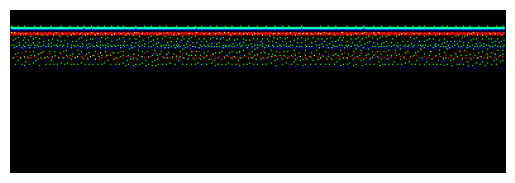

In [38]:
plt.imshow(df_expanded['stft'][30])
plt.axis('off')

In [45]:
img_folder = Path(r"/home/patryk/Desktop/engineering_thesis/MASTER_THIESIS/spectogram_ziemowit")

img_folder.mkdir(parents=True, exist_ok=True)

i = 0
prewous_name = None

for _, row in df_expanded.iterrows():
    img = Image.fromarray(row['stft'])
    label = row['name']
    id = row['file_name']

    if (id != prewous_name):
        prewous_name = id
    else:
        i += 1

    file_name = f"{id}_{i}_{label}.png"
    img.save(img_folder / file_name)